# 06 — Approved Model Test Submission

This notebook scores `data/processed/test_features.csv` with the model approved at the end of notebook 05 and writes `data/output/submission.csv`. The true label is isolated before scoring and attached only after prediction.

## Inference contract

1. Load only an artifact marked `approved_for_inference`.
2. Load `test_features.csv` and preserve `default_flag` separately as `true_label`.
3. Remove the target and leakage columns before the model sees the data.
4. Quarantine or reject invalid rows according to `configs/inference.yaml`.
5. Apply the threshold and risk bands frozen inside the model artifact.
6. Write exactly `predicted_label` and `true_label` to `submission.csv`.

In [1]:
import pandas as pd
from IPython.display import display

from bnpl_credit_risk.pipelines.batch_inference_pipeline import (
    BatchInferencePipeline,
)
from bnpl_credit_risk.settings import get_settings, load_config
from bnpl_credit_risk.visualization.inference import (
    BatchInferenceVisualizer,
)

settings = get_settings()
config = load_config()
batch_pipeline = BatchInferencePipeline(config=config, settings=settings)
batch_visualizer = BatchInferenceVisualizer(
    size=config.inference.visualization.size
)

## 1. Verify the deployed model

This cell intentionally fails if `latest` still points to a legacy or unapproved model. In that case, complete the publication cell at the end of notebook 05.

In [2]:
model_contract = batch_pipeline.describe_model()
display(pd.Series(model_contract, name="Published model contract").to_frame())

if not model_contract["ready_for_scoring"]:
    print("\nSCORING BLOCKED")
    print(model_contract["blocking_reason"])

,Published model contract
model_version,2026-08-28_131115
algorithm,CatBoost
workflow,boosting_benchmark_04_05
risk_scope,application_risk
approved_for_inference,True
ready_for_scoring,True
blocking_reason,None
decision_threshold,0.293952
input_features,"[age, monthly_income, credit_score, purchase_a..."
risk_bands,"[{'name': 'Low Risk', 'max_probability': 0.25}..."


## 2. Load the labeled test partition

The complete test partition is used. Its target is retained only for the final comparison and is automatically removed by the inference layer before prediction.

In [3]:
input_path = batch_pipeline.input_path
test_df = batch_pipeline.load_applications(input_path)

print(f"Input path: {input_path}")
print(f"Test shape: {test_df.shape}")
print(f"True label column: {config.data.target_column}")
display(test_df.head())

2026-08-28 13:35:28.924 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/test_features.csv rows=1035 columns=22


Input path: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/test_features.csv
Test shape: (1035, 22)
True label column: default_flag


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,default_flag,app_usage_frequency,...,debt_to_income_ratio,installment_amount,installment_burden_ratio,affordability_band,income_after_installment,credit_score_band,age_group,installment_term,transaction_month_sin,transaction_month_cos
0,6943,53,Salaried,72456.12,651,5000.00,Electronics,12,0,4.34,...,0.069007,416.666667,0.005751,Very Low,72039.453333,Fair,46-60,Extended,1.224647e-16,-1.000000e+00
1,2466,51,Unemployed,8685.72,324,3530.41,Beauty,3,1,9.39,...,0.406461,1176.803333,0.135487,Very High,7508.916667,Poor,46-60,Short,-8.660254e-01,5.000000e-01
2,6845,30,Self-Employed,84521.73,613,5000.00,Electronics,3,0,3.25,...,0.059156,1666.666667,0.019719,Low,82855.063333,Fair,26-35,Short,-8.660254e-01,-5.000000e-01
3,609,26,Salaried,36837.74,446,5000.00,Sports,6,0,8.85,...,0.135730,833.333333,0.022622,Moderate,36004.406667,Poor,26-35,Medium,-8.660254e-01,-5.000000e-01
4,8992,57,Self-Employed,45203.00,493,5000.00,Fashion,12,0,5.06,...,0.110612,416.666667,0.009218,Very Low,44786.333333,Poor,46-60,Extended,1.000000e+00,6.123234e-17


## 3. Build `submission.csv`

Validation, leakage protection, target isolation, scoring, label reconciliation and atomic output writing are handled by `BatchInferencePipeline`.

In [4]:
submission_result = None
if not model_contract["ready_for_scoring"]:
    print("Submission skipped: publish the approved model from notebook 05.")
else:
    submission_result = batch_pipeline.run_test_submission()
    display(
        pd.Series(
            submission_result.summary, name="Submission summary"
        ).to_frame()
    )
    display(submission_result.submission.head())

2026-08-28 13:35:28.981 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/test_features.csv rows=1035 columns=22
2026-08-28 13:35:29.001 | INFO     | bnpl_credit_risk.inference.batch:run:67 - Loaded model version=2026-08-28_131115 for batch scoring
2026-08-28 13:35:29.020 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/test_features.csv rows=1035 columns=22
2026-08-28 13:35:29.021 | WARNING  | bnpl_credit_risk.inference.batch:run:83 - Input contains target column 'default_flag' — dropped before scoring (not used)
2026-08-28 13:35:29.043 | INFO     | bnpl_credit_risk.data.cleaning:clean:45 - Cleaned dataframe rows=1035 columns=21
2026-08-28 13:35:29.065 | INFO     | bnpl_credit_risk.data.validation:validate:122 - Validation complete strategy=strict valid_rows=1035 invali

,Submission summary
model_version,2026-08-28_131115
decision_threshold,0.293952
n_rows,1035
output_path,/Users/surelmanda/3-Mlops-Databricks-Projects/...
columns,"[predicted_label, true_label]"


,predicted_label,true_label
0,0,0
1,1,1
2,0,0
3,1,0
4,1,0


## 4. Inspect predictions and true labels

The saved file contains exactly the requested `predicted_label` and `true_label` columns. Detailed probabilities remain available in memory for diagnostic visualization.

In [5]:
predictions = None
if submission_result is None:
    print("Inspection skipped: no approved submission.")
else:
    predictions = submission_result.detailed_predictions
    display(submission_result.submission)
    display(
        predictions.sort_values("default_probability", ascending=False).head(10)
    )

,predicted_label,true_label
0,0,0
1,1,1
2,0,0
3,1,0
4,1,0
...,...,...
1030,0,0
1031,1,0
1032,1,1
1033,1,1


,user_id,default_probability,predicted_default,decision_threshold,risk_band,model_version,scoring_timestamp,predicted_label,true_label
549,6134,0.772323,1,0.293952,Very High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
136,4501,0.765932,1,0.293952,Very High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
272,8168,0.737031,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
536,5835,0.732724,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
155,4431,0.720344,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
171,4458,0.714534,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
491,6564,0.704981,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
269,7073,0.679815,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1
337,4243,0.655908,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,0
434,7408,0.654518,1,0.293952,High Risk,2026-08-28_131115,2026-08-28T13:35:29.109598,1,1


## 5. Portfolio scoring overview

The figure combines risk bands, predicted default probabilities and the threshold-dependent decision distribution.

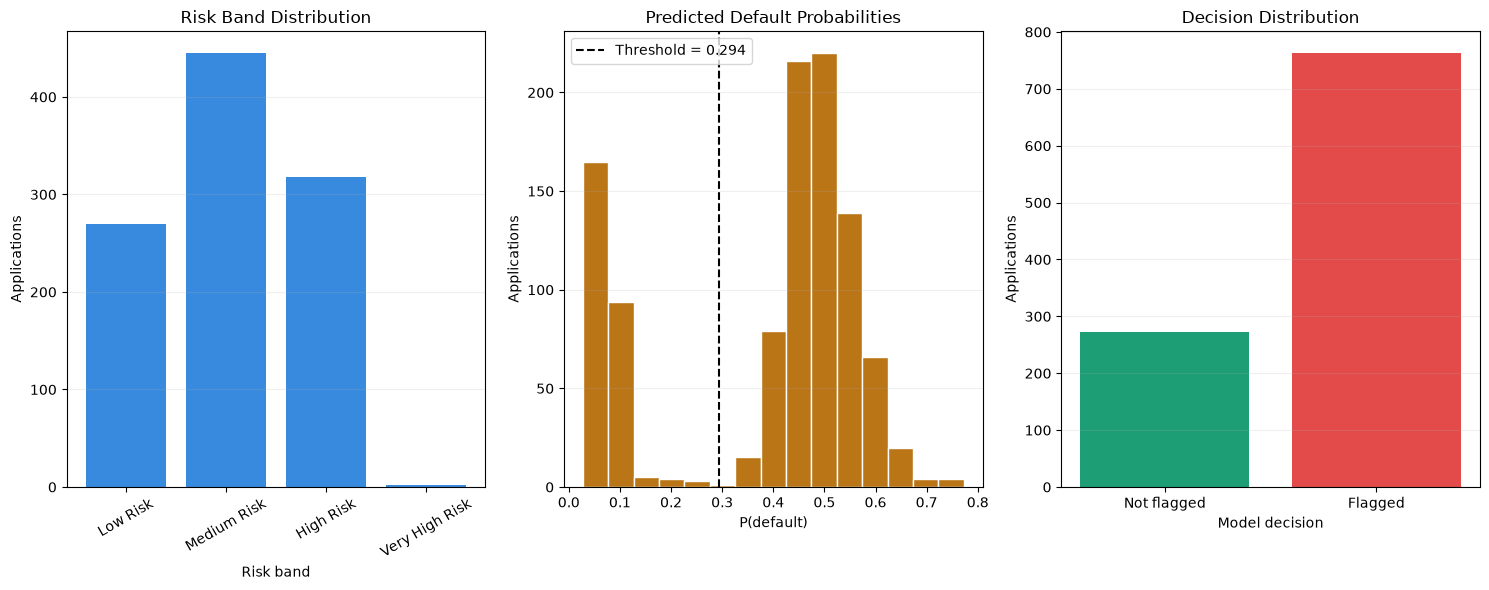

In [6]:
if predictions is None:
    print("Portfolio overview skipped: no approved predictions.")
else:
    display(
        batch_visualizer.portfolio_overview(
            predictions,
            threshold=submission_result.decision_threshold,
            risk_band_order=[band.name for band in config.training.risk_bands],
        )
    )